In [1]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import inv
import matplotlib.pyplot as plt

# Question 1

In [2]:
feature1 = [0.3510, 2.1812, 0.2415, -0.1096, 0.1544]
feature2 = [1.1796, 2.1068, 1.7753, 1.2747, 2.0851]
feature3 = [-0.9852, 1.3766, -1.3244, -0.6136, -0.8320]
target_y = [0.2758, 1.4392, -0.4611, 0.6154, 1.0006]

def Pearson_correlation(x, y):
    n = len(x)
    mu_x = sum(x) / n
    mu_y = sum(y) / n

    diff_x = [i - mu_x for i in x]
    diff_y = [i - mu_y for i in y]

    numerator = sum(dx*dy for dx, dy in zip(diff_x, diff_y))

    sum_sq_x = sum(dx**2 for dx in diff_x)
    sum_sq_y = sum(dy**2 for dy in diff_y)
    denominator = (sum_sq_x*sum_sq_y)**0.5

    return numerator/denominator

print(Pearson_correlation(feature1, target_y))
print(Pearson_correlation(feature2, target_y))
print(Pearson_correlation(feature3, target_y))


0.5987722845227615
0.4536921850899784
0.801591924992976


In [62]:
from scipy import stats
features = [feature1, feature2, feature3]
for i, feat in enumerate(features, 1):
    r, p_value = stats.pearsonr(feat, target_y)
    print(f"Feature {i} -> Correlation {r: .4f}")

Feature 1 -> Correlation  0.5988
Feature 2 -> Correlation  0.4537
Feature 3 -> Correlation  0.8016


## Question 2

In [63]:
#Training data
X_tr = np.array([[-10],[-8],[-3],[-1],[2],[7]])
y_tr = np.array([[4.18],[2.42],[0.22],[0.12],[0.25],[3.09]])

#Testing data
X_ts = np.array([[-9],[-7],[-5],[-4],[-2],[1],[4],[5],[6],[9]])
y_ts = np.array([[3],[1.81],[0.80],[0.25],[-0.19],[0.4],[1.24],[1.68],[2.32],[5.05]])

#Training model without regularization

#Calcuate model parameters
P_tr_list = []
P_ts_list = []
w_list = []
for i in range(1,7):
    poly = PolynomialFeatures(degree = i)
    P_tr = poly.fit_transform(X_tr)
    P_ts = poly.transform(X_ts)
    P_tr_list.append(P_tr)
    P_ts_list.append(P_ts)

    if P_tr_list[i-1].shape[0] > P_tr_list[i-1].shape[1]: #m > d
        w = inv(P_tr_list[i-1].T @ P_tr_list[i-1]) @ P_tr_list[i-1].T @ y_tr
    else: # m < d
        w = P_tr_list[i-1].T @ inv(P_tr_list[i-1] @ P_tr_list[i-1].T) @ y_tr

    w_list.append(w)
    #print(f"Degree {i} weights:\n{w}")

#Calculate MSE
y_pred_list = []
yts_pred_list = []
MSE_train_list = []
MSE_test_list = []
for i in range(0,6):
    y_pred = P_tr_list[i] @ w_list[i]
    y_ts_pred = P_ts_list[i] @ w_list[i]
    y_pred_list.append(y_pred)
    yts_pred_list.append(y_ts_pred)
    MSE_train = np.square(np.subtract(y_pred_list[i], y_tr)).mean()
    MSE_test = np.square(np.subtract(yts_pred_list[i], y_ts)).mean()

    MSE_train_list.append(MSE_train)
    MSE_test_list.append(MSE_test)
    print(f"MSE training for degree {i} is: {MSE_train}")
    print(f"MSE testing for degree {i} is: {MSE_test}")

MSE training for degree 0 is: 2.3070729253981557
MSE testing for degree 0 is: 3.0006478167488617
MSE training for degree 1 is: 0.008440835471198288
MSE testing for degree 1 is: 0.029594585750404308
MSE training for degree 2 is: 0.008302615907049128
MSE testing for degree 2 is: 0.030111281823536718
MSE training for degree 3 is: 0.0017347778137363496
MSE testing for degree 3 is: 0.08535502039489846
MSE training for degree 4 is: 1.194325891476633e-18
MSE testing for degree 4 is: 1.0548239860846322
MSE training for degree 5 is: 6.401136148106856e-17
MSE testing for degree 5 is: 10.767366473417336


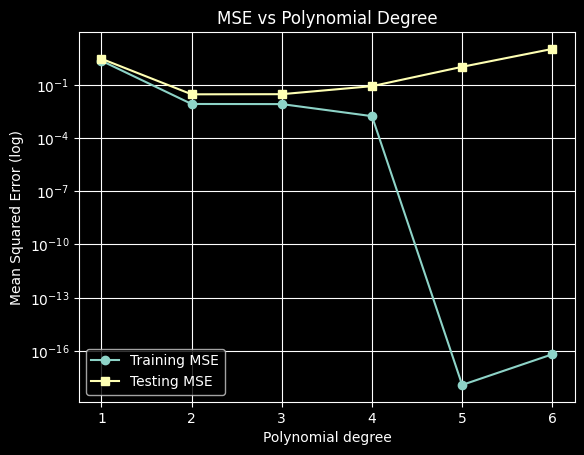

In [64]:
degrees = [1,2,3,4,5,6]
plt.plot(degrees, MSE_train_list, marker = 'o', label = 'Training MSE')
plt.plot(degrees, MSE_test_list, marker = 's', label = 'Testing MSE')

plt.yscale('log')

plt.xlabel('Polynomial degree')
plt.ylabel('Mean Squared Error (log)')
plt.title('MSE vs Polynomial Degree')
plt.legend()
plt.grid(True, which='both')
plt.show()

In [65]:
# With reguralization, lamd = 1
lamb = 1
#Training data
X_tr = np.array([[-10],[-8],[-3],[-1],[2],[7]])
y_tr = np.array([[4.18],[2.42],[0.22],[0.12],[0.25],[3.09]])

#Testing data
X_ts = np.array([[-9],[-7],[-5],[-4],[-2],[1],[4],[5],[6],[9]])
y_ts = np.array([[3],[1.81],[0.80],[0.25],[-0.19],[0.4],[1.24],[1.68],[2.32],[5.05]])

#Training model without regularization

#Calcuate model parameters
P_tr_list = []
P_ts_list = []
w_list = []
for i in range(1,7):
    poly = PolynomialFeatures(degree = i)
    P_tr = poly.fit_transform(X_tr)
    P_ts = poly.transform(X_ts)
    P_tr_list.append(P_tr)
    P_ts_list.append(P_ts)

    if P_tr_list[i-1].shape[0] > P_tr_list[i-1].shape[1]: #m > d
        w = inv(P_tr_list[i-1].T @ P_tr_list[i-1] + lamb * np.eye(P_tr_list[i-1].shape[1])) @ P_tr_list[i-1].T @ y_tr
    else: # m < d
        w = P_tr_list[i-1].T @ inv(P_tr_list[i-1] @ P_tr_list[i-1].T + lamb * np.eye(P_tr_list[i-1].shape[0])) @ y_tr

    w_list.append(w)
    #print(f"Degree {i} weights:\n{w}")

#Calculate MSE
y_pred_list = []
yts_pred_list = []
MSE_train_reg_list = []
MSE_test_reg_list = []
for i in range(0,6):
    y_pred = P_tr_list[i] @ w_list[i]
    y_ts_pred = P_ts_list[i] @ w_list[i]
    y_pred_list.append(y_pred)
    yts_pred_list.append(y_ts_pred)
    MSE_train = np.square(np.subtract(y_pred_list[i], y_tr)).mean()
    MSE_test = np.square(np.subtract(yts_pred_list[i], y_ts)).mean()

    MSE_train_reg_list.append(MSE_train)
    MSE_test_reg_list.append(MSE_test)
    print(f"MSE training for degree {i} is: {MSE_train_reg_list[i]}")
    print(f"MSE testing for degree {i} is: {MSE_test_reg_list[i]}")

MSE training for degree 0 is: 2.3585531011197105
MSE testing for degree 0 is: 3.2755677280832316
MSE training for degree 1 is: 0.008456477077018427
MSE testing for degree 1 is: 0.030169873887064814
MSE training for degree 2 is: 0.008356013483798866
MSE testing for degree 2 is: 0.03141714830425406
MSE training for degree 3 is: 0.0018079762223900304
MSE testing for degree 3 is: 0.0939314269840105
MSE training for degree 4 is: 0.0007264963729545007
MSE testing for degree 4 is: 0.4368968011631985
MSE training for degree 5 is: 0.00019347846088192897
MSE testing for degree 5 is: 6.020235939538185


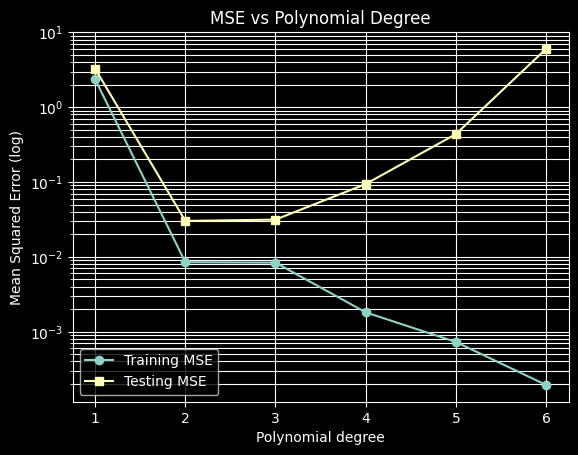

In [66]:
degrees = [1,2,3,4,5,6]
plt.plot(degrees, MSE_train_reg_list, marker = 'o', label = 'Training MSE')
plt.plot(degrees, MSE_test_reg_list, marker = 's', label = 'Testing MSE')

plt.yscale('log')

plt.xlabel('Polynomial degree')
plt.ylabel('Mean Squared Error (log)')
plt.title('MSE vs Polynomial Degree')
plt.legend()
plt.grid(True, which='both')
plt.show()

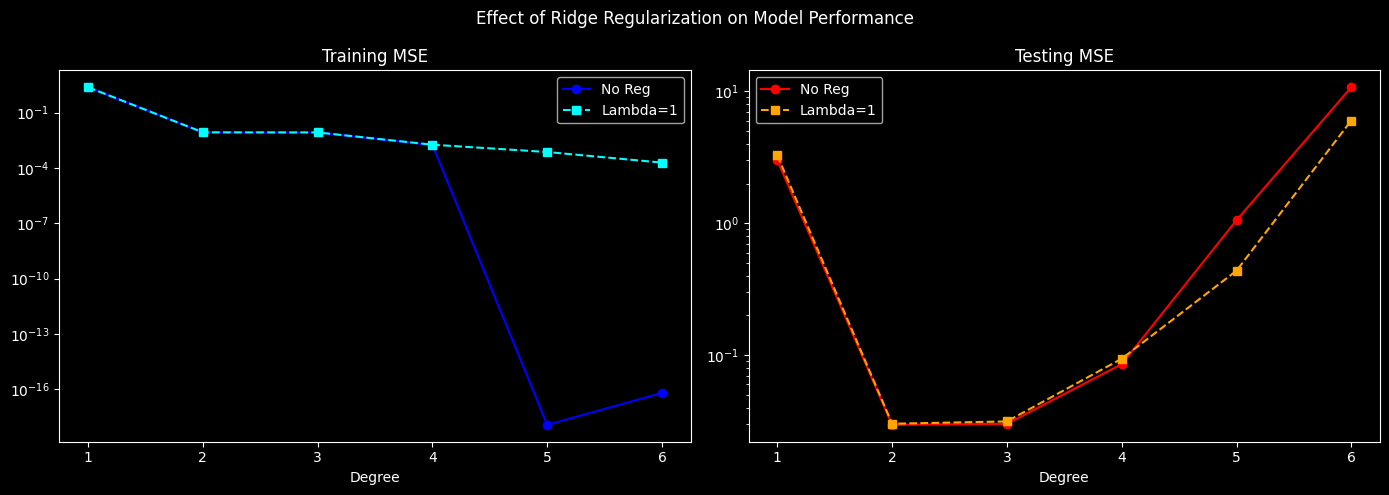

In [67]:
degrees = [1, 2, 3, 4, 5, 6]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training MSE Comparison
ax[0].plot(degrees, MSE_train_list, 'o-', label='No Reg', color='blue')
ax[0].plot(degrees, MSE_train_reg_list, 's--', label='Lambda=1', color='cyan')
ax[0].set_yscale('log')
ax[0].set_title('Training MSE')
ax[0].set_xlabel('Degree')
ax[0].legend()

# Plot 2: Testing MSE Comparison (The most important one!)
ax[1].plot(degrees, MSE_test_list, 'o-', label='No Reg', color='red')
ax[1].plot(degrees, MSE_test_reg_list, 's--', label='Lambda=1', color='orange')
ax[1].set_yscale('log')
ax[1].set_title('Testing MSE')
ax[1].set_xlabel('Degree')
ax[1].legend()

plt.suptitle('Effect of Ridge Regularization on Model Performance')
plt.tight_layout()
plt.show()